[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ushaloy/SAVE-LEWS/blob/main/notebooks/01_thailand_step1_richards_pinn.ipynb)

# B-PINN for LoRaWAN landslide EWS — Step 1: Richards profile PINN stepped in real time

**Scope of this notebook (step 1 only):** a *deterministic* discrete-time Richards PINN on a 0–1.2 m column,
stepped every 5 min, checked on **one Dev108 storm (6 Nov 2025, 61 mm)** and applied unchanged to the other six.
No Bayesian layer yet, no leave-one-storm-out yet. Rain nowcast = **oracle** (rain that actually fell) wherever labelled.

Three configurations share one network and one physics module:

| Config | Residual weight | Purpose |
|---|---|---|
| **A — weak residual** | λ = 1, residual scale 1e-5 s⁻¹ | a "typical" PINN weighting |
| **B — strong residual** | λ = 1, residual scale 1e-6 s⁻¹ | residual actually enforced during wet-up |
| **C — no physics** | λ = 0 | same network, same forcing, no Richards residual (ablation) |

An **independent backward-Euler Newton solver** with the same parameters checks whether each network's profile is really a Richards solution.

Set `TRAIN = True` to refit (≈15 min per config on a Colab CPU); `False` loads the checkpoints in `checkpoints/`.

In [1]:
# Setup (Colab)
import os, sys, subprocess
REPO_URL = 'https://github.com/Ushaloy/SAVE-LEWS'   # <-- set this to your GitHub repository before running in Colab
def _repo_root():
    here = os.getcwd()
    for c in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here)), '/content/SAVE-LEWS', os.path.join(here, 'SAVE-LEWS')]:
        if os.path.exists(os.path.join(c, 'thailand', 'data_pipeline.py')):
            return c
    dst = '/content/SAVE-LEWS' if 'google.colab' in sys.modules else os.path.join(here, 'SAVE-LEWS')
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, dst], check=True)
    return dst
ROOT = _repo_root(); os.chdir(os.path.join(ROOT, 'thailand')); sys.path.insert(0, os.getcwd())
for _pkg, _mod in [('numpyro', 'numpyro'), ('optax', 'optax'), ('openpyxl', 'openpyxl')]:
    try: __import__(_mod)
    except ImportError: subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _pkg], check=True)
DATA = '../data/thailand'
print('repository:', ROOT, '| working folder:', os.getcwd())
TRAIN = False          # True = refit all three configs
ITERS = 1500
import numpy as np, pandas as pd, torch, json, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore'); torch.set_num_threads(2)
print(torch.__version__, DATA)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repository: /content/SAVE-LEWS | working folder: /content/SAVE-LEWS/thailand


2.14.0+cu130 ../data/thailand


## 1. Data pipeline
Rain: the `rain` column is a tipping-bucket counter (0.2794 mm/tip) that resets hourly and was interpolated to 1-min rows.
Increments = positive counter differences **plus the bottom value of each interpolated reset ramp** (the true counter restarted at 0,
so that value is new-hour rain). This reproduces the 437 mm total for Dev108. 5-min grid; empty bins stay NaN (missing, not dry).
θ is corrected for the −0.0009 m³/m³ per °C temperature artifact. Dev108 rows before 1 Nov 10:40 are pre-installation (θ ≈ 0.05) and dropped.

In [2]:
"""Shared data pipeline: Dev107/108 -> 5-min grid with reset-aware rain increments."""
import numpy as np, pandas as pd
TIP_MM = 0.2794

def load_device(path, temp_coef=-0.0009, tref=None):
    d = pd.read_csv(path)
    d['t'] = pd.to_datetime(d.timestamp, format='%m/%d/%Y %H:%M')
    d = d.sort_values('t', kind='stable').groupby('t').agg(
        rain=('rain', 'last'), soil=('soil', 'mean'), temp=('temp', 'mean'))
    c = d.rain.values
    dif = np.diff(c, prepend=c[0])
    inc = np.clip(dif, 0, None)
    # a descent = interpolated hourly reset; the true counter restarted at 0,
    # so the bottom value of the descent is already new-hour rain
    bottom = (dif < 0) & (np.r_[dif[1:], 0] >= 0)
    inc = inc + c * bottom
    d['rain_inc'] = inc
    g = pd.DataFrame({
        'rain': d.rain_inc.resample('5min').sum(min_count=1),   # empty bin -> NaN (missing, not dry)
        'theta_raw': d.soil.resample('5min').mean(),
        'temp': d.temp.resample('5min').mean(),
        'n_raw': d.soil.resample('5min').count()})
    tref = g.temp.mean() if tref is None else tref
    # sensor reads low when warm: remove the artifact
    g['theta'] = g.theta_raw - temp_coef * (g.temp - tref)
    return g

def storm_catalogue(g, min_total=10.0, dry_gap_h=6.0):
    """Storms = rain clusters separated by >= dry_gap_h hours with no rain; keep total >= min_total."""
    r = g.rain.fillna(0)
    wet = r[r > 0].index
    storms, start, last, tot = [], None, None, 0.0
    for t in wet:
        if start is None or (t - last) > pd.Timedelta(hours=dry_gap_h):
            if start is not None: storms.append((start, last, tot))
            start, tot = t, 0.0
        tot += r[t]; last = t
    if start is not None: storms.append((start, last, tot))
    s = pd.DataFrame(storms, columns=['start', 'end', 'rain_mm'])
    return s[s.rain_mm >= min_total].reset_index(drop=True)


In [3]:
g108 = load_device(f'{DATA}/pinn_108_new.csv').loc['2025-11-01 10:40':]
g107 = load_device(f'{DATA}/107_pinn.csv')
print('Dev108 rain %.1f mm' % load_device(f'{DATA}/pinn_108_new.csv').rain.sum(), '| Dev107 rain %.1f mm' % g107.rain.sum())
S108, S107 = storm_catalogue(g108), storm_catalogue(g107)
S108

Dev108 rain 437.1 mm | Dev107 rain 285.6 mm


,start,end,rain_mm
0,2025-11-06 03:00:00,2025-11-06 14:15:00,61.328300
1,2025-11-10 06:10:00,2025-11-10 13:15:00,15.367000
2,2025-11-19 03:45:00,2025-11-20 15:35:00,244.265448
3,2025-12-25 22:45:00,2025-12-26 14:30:00,18.170000
4,2025-12-28 13:05:00,2025-12-29 00:50:00,32.990000
5,2026-01-21 17:50:00,2026-01-22 01:55:00,10.060000
6,2026-01-25 00:05:00,2026-01-25 05:20:00,15.920000


### 1-D water-balance check at the sensor
For the largest 60-min rise at 30 cm in each storm: if all rain in that hour stayed in a 1-D column,
the wetted layer could be at most `rain / Δθ` thick. Small values mean the rise needs **all** rain concentrated in a thin layer
around the probe; values below a few cm are impossible in 1-D (lateral inflow, preferential path at the probe, or rain-timing error).

In [4]:
rows = []
for dev, g, S in [(108, g108, S108), (107, g107, S107)]:
    for i, st in S.iterrows():
        w = g.loc[st.start - pd.Timedelta('1h'): st.end + pd.Timedelta('3h')]
        roll = w.theta.shift(-12) - w.theta; t0 = roll.idxmax(); dth = roll.max()
        rr = w.rain.fillna(0).loc[t0: t0 + pd.Timedelta('60min')].sum()
        rows.append(dict(dev=dev, storm=i, start=st.start.date(), total_mm=round(st.rain_mm, 1),
                         theta_start=round(w.theta.loc[t0], 3), max_60min_rise=round(dth, 3),
                         rain_that_hour_mm=round(rr, 1), max_1D_wetted_thickness_cm=round(rr / 1000 / dth * 100, 1)))
WB = pd.DataFrame(rows); WB

,dev,storm,start,total_mm,theta_start,max_60min_rise,rain_that_hour_mm,max_1D_wetted_thickness_cm
0,108,0,2025-11-06,61.3,0.451,0.088,29.6,33.7
1,108,1,2025-11-10,15.4,0.429,0.058,8.0,13.7
2,108,2,2025-11-19,244.3,0.510,0.022,29.5,136.4
3,108,3,2025-12-25,18.2,0.404,0.042,4.2,9.9
4,108,4,2025-12-28,33.0,0.472,0.036,13.8,38.8
5,108,5,2026-01-21,10.1,0.386,0.041,5.7,14.1
6,108,6,2026-01-25,15.9,0.472,0.035,5.9,16.9
7,107,0,2025-11-10,15.9,0.330,0.100,10.6,10.6
8,107,1,2025-11-19,207.9,0.430,0.028,18.2,64.4
9,107,2,2025-12-25,17.6,0.293,0.031,0.3,0.9


## 2. Model: physics module, PINN stepper, residual
Richards (mixed form, z positive down): ∂θ/∂t = −∂q/∂z + S, q = K(θ)(1 − ∂h/∂z), van Genuchten–Mualem K, h.
Surface flux = matrix share (1−β) of effective rain; free drainage at 1.2 m; **S** = bypass share β delivered around depth z_b (Gaussian, width w_b).
Effective rain passes an interception / initial-abstraction store of capacity **c** that empties with time constant τ.
The residual is backward-Euler: fluxes evaluated at the network's proposed θ^{k+1}. θr = 0.05, θs = 0.55 fixed.

In [5]:
"""
Step 1: discrete-time Richards profile PINN stepped in real time (dt = 5 min).

State: theta(z) on a 30-cell column, dz = 4 cm, 0-1.2 m (cell centres 2,6,...,118 cm;
the 30 cm sensor is cell 7, the 1.0 m failure plane is the mean of cells 24/25).

Per step k -> k+1 the network proposes the whole profile theta^{k+1}. It is trained with
  (a) data loss on the 30 cm cell (multi-step open-loop forecasts, 30/60/120 min), and
  (b) the implicit (backward-Euler) Richards residual of its own proposal
      R_i = (theta_i^{k+1} - theta_i^k)/dt - [(q_{i-1/2} - q_{i+1/2})/dz + S_i]
      with Darcy fluxes q from van Genuchten K(theta^{k+1}), h(theta^{k+1}) (z down, q down +),
      surface flux = matrix share of effective rain, free drainage at 1.2 m,
      S_i = macropore (bypass) delivery of effective rain around depth z_b.
Effective rain passes an interception/initial-abstraction store of capacity c (learned),
which empties with time constant tau between storms.
Learned physical parameters: Ks, alpha, n, c, tau, bypass fraction beta, z_b, bypass width.
theta_r, theta_s fixed (Dev108: 0.05 / 0.55).
"""
import math, numpy as np, torch, torch.nn as nn, torch.nn.functional as F

DT = 300.0                       # s
DZ = 0.04                        # m
NZ = 30
Z = (torch.arange(NZ) + 0.5) * DZ  # cell centres, m
I_OBS = 7                        # z = 0.30 m
I_FAIL = (24, 25)                # z = 0.98 / 1.02 -> 1.0 m

def bounded(raw, lo, hi, log=False):
    s = torch.sigmoid(raw)
    if log:
        return torch.exp(math.log(lo) + s * (math.log(hi) - math.log(lo)))
    return lo + s * (hi - lo)

def inv_bounded(v, lo, hi, log=False):
    if log:
        s = (math.log(v) - math.log(lo)) / (math.log(hi) - math.log(lo))
    else:
        s = (v - lo) / (hi - lo)
    s = min(max(s, 1e-4), 1 - 1e-4)
    return math.log(s / (1 - s))

# (name, lo, hi, log, init)   a priori: Ks 0.0043 m/h, alpha 5.9 1/m, n 1.48
PARAM_SPEC = [
    ('Ks_mph', 1e-4, 1.0, True, 0.0043),
    ('alpha',  0.5, 20.0, True, 5.9),
    ('n',      1.1, 3.0, False, 1.48),
    ('c_mm',   0.0, 15.0, False, 5.0),    # interception / initial-abstraction capacity
    ('tau_h',  1.0, 72.0, True, 6.0),     # store emptying time constant
    ('beta',   0.0, 1.0, False, 0.5),     # bypass fraction of effective rain
    ('zb',     0.05, 1.0, False, 0.30),   # bypass delivery depth
    ('wb',     0.02, 0.5, True, 0.10),    # bypass delivery width
]

# convergent lateral inflow (linear reservoir fed by gamma x effective rain, released around z_l)
# and lateral drainage sink lam_out * K(theta)  [1/m * m/s = 1/s]
LATERAL_SPEC = [
    ('gamma',     0.0, 5.0, False, 0.5),
    ('tau_lat_h', 0.05, 24.0, True, 0.5),
    ('zl',        0.05, 1.0, False, 0.30),
    ('wl',        0.02, 0.5, True, 0.08),
    ('lam_out',   0.01, 1e4, True, 1.0),
]

# fast (macropore) domain at the probe: store F (mm) fed by beta x effective rain,
# drains out of the column (tau_fd) and exchanges into the matrix around z_b (tau_fx);
# the probe reads theta_m + (theta_s - theta_m) * tanh(kappa * F)
FAST_SPEC = [
    ('kappa',    1e-3, 1.0, True, 0.03),
    ('tau_fd_h', 0.05, 12.0, True, 0.5),
    ('tau_fx_h', 0.05, 48.0, True, 2.0),
]

# bounded fast domain: macropore water can add at most phi_f (macropore porosity, <= 5 %) to the probe reading
BOUNDED_SPEC = [('phi_f', 0.005, 0.05, False, 0.02)]

class Physics(nn.Module):
    def __init__(self, theta_r=0.05, theta_s=0.55, init=None, lateral=False, fast=False, bounded=False):
        super().__init__()
        self.tr, self.ts = theta_r, theta_s
        self.lateral, self.fast, self.bounded = lateral, fast, bounded
        spec = (PARAM_SPEC + (LATERAL_SPEC if lateral else []) + (FAST_SPEC if fast else [])
                + (BOUNDED_SPEC if bounded else []))
        init = init or {}
        self.raw = nn.ParameterDict({
            n: nn.Parameter(torch.tensor(inv_bounded(init.get(n, v0), lo, hi, lg)))
            for n, lo, hi, lg, v0 in spec})
        self.spec = {n: (lo, hi, lg) for n, lo, hi, lg, _ in spec}

    def p(self, name):
        lo, hi, lg = self.spec[name]
        return bounded(self.raw[name], lo, hi, lg)

    def values(self):
        return {n: float(self.p(n)) for n in self.spec}

    # van Genuchten-Mualem
    def Se(self, th):
        return ((th - self.tr) / (self.ts - self.tr)).clamp(1e-3, 0.999)

    def h(self, th):                       # pressure head, m (negative)
        n = self.p('n'); m = 1 - 1 / n; a = self.p('alpha')
        lg = (-(1 / m) * torch.log(self.Se(th))).clamp(max=25.0)   # overflow-safe
        return -(1 / a) * torch.expm1(lg).clamp_min(1e-12) ** (1 / n)

    def K(self, th):                       # m/s
        n = self.p('n'); m = 1 - 1 / n; se = self.Se(th)
        Ks = self.p('Ks_mph') / 3600.0
        return Ks * se.sqrt() * (1 - (1 - se ** (1 / m)) ** m) ** 2

    def bypass_weights(self):
        w = torch.exp(-0.5 * ((Z - self.p('zb')) / self.p('wb')) ** 2)
        return w / w.sum()

    def interception(self, store, rain_mm):
        """store (B,), rain_mm (B,) for one 5-min step -> (new store, effective rain mm)."""
        c = self.p('c_mm')
        s = store * torch.exp(-DT / 3600.0 / self.p('tau_h')) + rain_mm
        eff = F.softplus(s - c, beta=20.0)          # smooth overflow
        return s - eff, eff

    def gauss(self, zc, w):
        g = torch.exp(-0.5 * ((Z - zc) / w) ** 2)
        return g / g.sum()

    def drive(self, rain):
        """rain (T,) or (W,T) mm/5min -> drive (T,C) or (W,T,C):
        [effective rain, lateral inflow, (fast exchange, fast store F)] in mm per 5-min step."""
        if rain.dim() == 2:
            return self._drive(rain)
        return self._drive(rain[None])[0]

    def fast_decay(self):
        kd, kx = 1 / self.p('tau_fd_h'), 1 / self.p('tau_fx_h')
        return torch.exp(-DT / 3600.0 * (kd + kx)), kx / (kd + kx)

    def _drive(self, rain):
        W = rain.shape[0]
        store = torch.zeros(W); L = torch.zeros(W); Fs = torch.zeros(W); out = []
        if self.lateral:
            dec = torch.exp(-DT / 3600.0 / self.p('tau_lat_h')); gam = self.p('gamma')
        if self.fast:
            fdec, fx = self.fast_decay(); beta = self.p('beta')
        for k in range(rain.shape[1]):
            store, e = self.interception(store, rain[:, k])
            if self.lateral:
                rel = L * (1 - dec); L = L - rel + gam * e
            else:
                rel = torch.zeros(W)
            if self.fast:
                lost = Fs * (1 - fdec); exch = lost * fx; Fs = Fs - lost + beta * e
                out.append(torch.stack([e, rel, exch, Fs], -1))
            else:
                out.append(torch.stack([e, rel], -1))
        return torch.stack(out, 1)

    def sensor(self, th_obs_cell, F_mm):
        """probe reading from matrix theta at the probe cell and fast-domain store (identity if no fast domain)."""
        if not self.fast:
            return th_obs_cell
        if self.bounded:
            return (th_obs_cell + self.p('phi_f') * torch.tanh(self.p('kappa') * F_mm)).clamp(max=self.ts)
        return th_obs_cell + (self.ts - th_obs_cell) * torch.tanh(self.p('kappa') * F_mm)

    def sensor_inverse(self, obs, F_mm):
        """matrix theta at the probe consistent with an observation."""
        if not self.fast:
            return obs
        if self.bounded:
            return obs - self.p('phi_f') * torch.tanh(self.p('kappa') * F_mm)
        t = torch.tanh(self.p('kappa') * F_mm)
        return (obs - self.ts * t) / (1 - t).clamp_min(1e-3)

    def forcing(self, th, drive):
        """surface flux q0 (B,) and internal source S (B,NZ) in m/s, limited by free storage.
        drive (B,2) = [effective rain mm, lateral inflow mm] per 5-min step (legacy: (B,) rain only)."""
        if drive.dim() == 1:
            drive = torch.stack([drive, torch.zeros_like(drive)], 1)
        eff_mm, lat_mm = drive[:, 0], drive[:, 1]
        p = eff_mm / 1000.0 / DT                              # m/s
        room = 1 - self.Se(th)
        avail = room / (room + 0.02)                          # ~1 unless near saturation; excess -> runoff
        beta = self.p('beta')
        q0 = (1 - beta) * p * avail[:, 0]
        if self.fast:   # macropore water enters the matrix by delayed exchange, not instantly
            S = (drive[:, 2] / 1000.0 / DT)[:, None] * self.bypass_weights()[None, :] * avail / DZ
        else:
            S = beta * p[:, None] * self.bypass_weights()[None, :] * avail / DZ
        if self.lateral:
            S = S + (lat_mm / 1000.0 / DT)[:, None] * self.gauss(self.p('zl'), self.p('wl'))[None, :] * avail / DZ
        return q0, S

    def rhs(self, th, q0, S):
        """d theta/dt (B,NZ) plus flux divergence term, evaluated at profile th."""
        K = self.K(th); h = self.h(th)
        Kf = 0.5 * (K[:, 1:] + K[:, :-1])
        q_int = Kf * (1 - (h[:, 1:] - h[:, :-1]) / DZ)       # downward positive
        q = torch.cat([q0[:, None], q_int, K[:, -1:]], dim=1) # (B, NZ+1), free drainage at bottom
        div = (q[:, :-1] - q[:, 1:]) / DZ                      # -dq/dz
        f = div + S
        if self.lateral:
            f = f - self.p('lam_out') * K                      # lateral (slope-parallel) drainage
        return f, div, q

class Stepper(nn.Module):
    """1-D conv net proposing theta^{k+1} from theta^k and forcing; storage-bounded output."""
    def __init__(self, phys, width=32):
        super().__init__()
        self.phys = phys
        cin = 6
        self.net = nn.Sequential(
            nn.Conv1d(cin, width, 5, padding=2), nn.SiLU(),
            nn.Conv1d(width, width, 5, padding=2), nn.SiLU(),
            nn.Conv1d(width, width, 5, padding=2), nn.SiLU(),
            nn.Conv1d(width, 2, 1))
        nn.init.zeros_(self.net[-1].weight)
        with torch.no_grad():
            self.net[-1].bias.fill_(-6.0)

    def forward(self, th, drive):
        ph = self.phys
        q0, S = ph.forcing(th, drive)
        f_expl, _, _ = ph.rhs(th, q0, S)
        B = th.shape[0]
        se = ph.Se(th)
        x = torch.stack([
            se,
            torch.log10(-ph.h(th) + 1e-4) / 3,
            Z[None, :].expand(B, -1),
            (q0[:, None] * DT / DZ * 10).expand(-1, NZ),     # surface input, scaled
            S * DT * 10,
            torch.tanh(f_expl * DT * 20),                   # explicit physics hint (bounded)
        ], dim=1)
        a = self.net(x)
        tr, ts = ph.tr, ph.ts
        th_new = th + (ts - th) * torch.sigmoid(a[:, 0]) - (th - tr) * torch.sigmoid(a[:, 1])
        return th_new, q0, S

def residual(phys, th_old, th_new, q0, S):
    f, div, q = phys.rhs(th_new, q0, S)
    dthdt = (th_new - th_old) / DT
    return dthdt - f, dthdt, div, S


## 3. Independent implicit solver (verification + physics-only reference)

In [6]:
"""Independent backward-Euler Richards solver (Newton, dense Jacobian per column) with the
same parameterisation/forcing as the PINN. Used to (i) verify that the PINN's profile is a
Richards solution and (ii) as a physics-only baseline."""
import torch
from torch.func import jacrev, vmap

@torch.no_grad()
def be_step(phys, th, eff_mm, nsub=2, newton=8):
    """th (B,NZ) -> th_new (B,NZ); forcing frozen at start of step as in the PINN."""
    q0, S = phys.forcing(th, eff_mm)
    dt = DT / nsub
    lo, hi = phys.tr + 1e-4, phys.ts - 1e-4
    for _ in range(nsub):
        old = th
        def G(x, xo, q0_, S_):
            f, _, _ = phys.rhs(x[None], q0_[None], S_[None])
            return x - xo - dt * f[0]
        x = old.clone()
        for _ in range(newton):
            r = vmap(G)(x, old, q0, S)
            J = vmap(jacrev(G))(x, old, q0, S)
            dx = torch.linalg.solve(J, -r.unsqueeze(-1)).squeeze(-1)
            x = (x + dx.clamp(-0.05, 0.05)).clamp(lo, hi)
        th = x
    return th

@torch.no_grad()
def solver_forecast(phys, th0, eff_seq):
    th = th0; traj = []
    for j in range(eff_seq.shape[1]):
        th = be_step(phys, th, eff_seq[:, j]); traj.append(th)
    return torch.stack(traj, 1)


## 4. Training and evaluation
Training storm: Dev108 storm 0 (6 Nov 2025), window = 48 h spin-up + storm + 24 h.
Real-time analysis pass: step the profile, nudge a Gaussian neighbourhood (σ = 8 cm) of the 30 cm cell to each observation.
Data loss: open-loop Δθ at 30/60/120 min from analysis states, normalised by persistence MSE. Physics loss: residual on analysis steps and along forecasts,
storm-weighted sampling, λ ramped over the first 40 % of iterations.
**Storm-time** = storm start − 1 h to end + 6 h. Skill = 1 − MSE/MSE_persistence on Δθ at 30 cm. **Oracle** = future rain that actually fell; **past** = future rain set to 0.

In [7]:
"""Training / evaluation utilities for the step-1 Richards profile PINN."""
import numpy as np, pandas as pd, torch, time

HORIZONS = (6, 12, 24)        # 30 / 60 / 120 min
R_SCALE = 1e-5                # s^-1, scale for the Richards residual (storm dtheta/dt ~ 1e-5..1e-4)

def make_window(g, storm, pre_h=48, post_h=24):
    w = g.loc[storm.start - pd.Timedelta(hours=pre_h): storm.end + pd.Timedelta(hours=post_h)]
    rain = w.rain.values.astype(np.float32)
    obs = w.theta.values.astype(np.float32)
    in_storm = ((w.index >= storm.start - pd.Timedelta(hours=1)) &
                (w.index <= storm.end + pd.Timedelta(hours=6)))
    return dict(t=w.index, rain=torch.tensor(np.nan_to_num(rain)), rain_missing=np.isnan(rain),
                obs=torch.tensor(obs), obs_ok=torch.tensor(~np.isnan(obs)),
                in_storm=torch.tensor(in_storm), name=str(storm.start.date()),
                rain_mm=float(storm.rain_mm))

def nudge_gain(L=0.08):
    return torch.exp(-0.5 * ((Z - Z[I_OBS]) / L) ** 2)

def eff_rain(phys, rain):
    """drive series (T,2): [effective rain mm, lateral inflow mm]."""
    return phys.drive(rain)

@torch.no_grad()
def analysis(model, win, eff):
    """Real-time assimilation pass: step the profile, nudge the 30 cm neighbourhood to obs."""
    obs, ok = win['obs'], win['obs_ok']
    first = obs[ok][0]
    th = torch.full((1, NZ), float(first))
    G = nudge_gain()
    states = [th]
    for k in range(len(obs) - 1):
        th, _, _ = model(th, eff[k:k + 1])
        if ok[k + 1]:
            th = th + G * (obs[k + 1] - th[:, I_OBS])
            th = th.clamp(model.phys.tr + 1e-3, model.phys.ts - 1e-3)
        states.append(th)
    return torch.cat(states)          # (T, NZ): analysis state at each time

def forecast(model, th0, eff_seq, H):
    """open-loop rollouts. th0 (B,NZ); eff_seq (B,H) effective rain. returns list of states."""
    th = th0; traj = []; res = []
    for j in range(H):
        th_new, q0, S = model(th, eff_seq[:, j])
        R, *_ = residual(model.phys, th, th_new, q0, S)
        res.append(R); traj.append(th_new); th = th_new
    return torch.stack(traj, 1), torch.stack(res, 1)

def origins_and_targets(win, H=24, stride=1):
    obs, ok = win['obs'], win['obs_ok']
    T = len(obs)
    idx = [k for k in range(0, T - H, stride) if ok[k]]
    return torch.tensor(idx)

def future_eff(eff, idx, H, oracle=True):
    if oracle:
        return torch.stack([eff[i:i + H] for i in idx.tolist()])
    return torch.zeros(len(idx), H, eff.shape[-1])

def train(win, lam=1.0, r_scale=R_SCALE, ramp=0.4, storm_weight_residual=True, event_weight=0.0, lateral=False, iters=1500, lr=3e-3, seed=0, refresh=25, batch=64, log_every=250,
          init=None, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    phys = Physics(init=init, lateral=lateral); model = Stepper(phys)
    opt = torch.optim.Adam([{'params': model.net.parameters(), 'lr': lr},
                            {'params': phys.parameters(), 'lr': lr * 3}])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, iters)
    H = max(HORIZONS)
    idx_all = origins_and_targets(win, H)
    obs, ok = win['obs'], win['obs_ok']
    # persistence MSE per horizon (normaliser) on training origins
    pers = []
    for h in HORIZONS:
        m = ok[idx_all + h]
        pers.append(((obs[idx_all + h] - obs[idx_all])[m] ** 2).mean())
    pers = torch.stack(pers).clamp_min(1e-8)
    # storm-heavy sampling: most of the information is in the storm
    wts = torch.where(win['in_storm'][idx_all], 4.0, 1.0)
    hist = []
    t0 = time.time()
    for it in range(iters):
        eff = eff_rain(phys, win['rain'])
        if it % refresh == 0:
            A = analysis(model, win, eff.detach())
        b = idx_all[torch.multinomial(wts, batch, replacement=True)]
        traj, R = forecast(model, A[b], future_eff(eff, b, H), H)
        l_data = 0
        for j, h in enumerate(HORIZONS):
            m = ok[b + h]
            pred = traj[:, h - 1, I_OBS] - A[b, I_OBS]
            targ = obs[b + h] - obs[b]
            l_data = l_data + ((pred - targ)[m] ** 2).mean() / pers[j]
        l_data = l_data / len(HORIZONS)
        # residual on analysis states (one-step) + along forecasts
        wk = torch.where(win['in_storm'][:-1], 4.0 if storm_weight_residual else 1.0, 1.0)
        if event_weight > 0:   # emphasise steps where the sensor actually moves
            dob = torch.nan_to_num((win['obs'][1:] - win['obs'][:-1]).abs(), 0.0)
            wk = wk * (1 + event_weight * (dob / 0.002).clamp(max=5.0))
        k = torch.multinomial(wk, batch, replacement=True)
        th1, q0, S = model(A[k], eff[k])
        R1, *_ = residual(phys, A[k], th1, q0, S)
        l_phys = 0.5 * ((R1 / r_scale) ** 2).mean() + 0.5 * ((R / r_scale) ** 2).mean()
        lam_it = lam * (min(1.0, 0.01 + it / max(1, ramp * iters)) if ramp > 0 else 1.0)
        loss = l_data + lam_it * l_phys
        opt.zero_grad()
        if not torch.isfinite(loss):
            continue
        loss.backward()
        if any(p.grad is not None and not torch.isfinite(p.grad).all() for p in model.parameters()):
            opt.zero_grad(); continue
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step(); sched.step()
        hist.append((float(l_data.detach()), float(l_phys.detach())))
        if verbose and (it % log_every == 0 or it == iters - 1):
            pv = phys.values()
            print(f"it {it:5d} data {float(l_data):.4f} phys {float(l_phys):.4f} | "
                  f"Ks {pv['Ks_mph']:.4g} a {pv['alpha']:.3g} n {pv['n']:.3g} c {pv['c_mm']:.2f} "
                  f"beta {pv['beta']:.2f} zb {pv['zb']:.2f} | {time.time()-t0:.0f}s", flush=True)
    return model, np.array(hist)

@torch.no_grad()
def evaluate(model, win, oracle=True):
    phys = model.phys
    H = max(HORIZONS)
    eff = eff_rain(phys, win['rain'])
    A = analysis(model, win, eff)
    idx = origins_and_targets(win, H)
    traj, R = forecast(model, A[idx], future_eff(eff, idx, H, oracle), H)
    obs, ok, st = win['obs'], win['obs_ok'], win['in_storm']
    out = {}
    for h in HORIZONS:
        m = ok[idx + h]
        pred = traj[:, h - 1, I_OBS] - A[idx, I_OBS]
        targ = obs[idx + h] - obs[idx]
        for tag, sel in [('all', m), ('storm', m & st[idx])]:
            mse = ((pred - targ)[sel] ** 2).mean(); mp = (targ[sel] ** 2).mean()
            out[f'skill_{tag}_{h*5}'] = float(1 - mse / mp)
    # constraint violations on forecasts
    dth = traj[:, :, I_OBS] - torch.cat([A[idx, None, I_OBS], traj[:, :-1, I_OBS]], 1)
    # rain (as fed to the model) in the preceding 3 h at each forecast step
    rain_in = win['rain'].clone()
    if not oracle:
        pass  # future rain is zero in past-only mode; history still observed
    csum = torch.cat([torch.zeros(1), torch.cumsum(rain_in, 0)])
    tstep = idx[:, None] + torch.arange(1, H + 1)[None, :]
    fut = torch.where(torch.tensor(oracle), torch.ones(()), (tstep <= idx[:, None]).float())
    r3h = csum[tstep + 1] - csum[(tstep - 35).clamp_min(0)]
    dry = r3h <= 0 if oracle else ((csum[idx + 1] - csum[(idx - 35).clamp_min(0)])[:, None] <= 0)
    out['viol_wet_without_rain'] = float(((dth > 1e-4) & dry).float().mean())
    out['viol_above_theta_s'] = float((traj > phys.ts + 1e-6).float().mean())
    # physics magnitudes along the analysis trajectory (network one-step proposals)
    th1, q0, S = model(A[:-1], eff[:-1])
    Rr, dthdt, div, Ssrc = residual(phys, A[:-1], th1, q0, S)
    stm = st[:-1]
    for tag, sel in [('storm', stm), ('quiet', ~stm)]:
        for nm, v in [('dthdt', dthdt), ('div', div), ('S', Ssrc), ('R', Rr)]:
            a = v[sel].abs()
            out[f'{nm}_{tag}_med'] = float(a.median())
            out[f'{nm}_{tag}_p95'] = float(torch.quantile(a.flatten()[:200000], 0.95))
        out[f'R_over_dthdt_{tag}'] = float(Rr[sel].abs().mean() / dthdt[sel].abs().mean().clamp_min(1e-20))
    out['eff'] = eff; out['A'] = A; out['idx'] = idx; out['traj'] = traj
    return out


In [8]:
CONFIGS = {'A_weak': dict(lam=1.0, r_scale=1e-5, ramp=0, storm_weight_residual=False), 'B_strong': dict(lam=1.0, r_scale=1e-6), 'C_nophys': dict(lam=0.0, r_scale=1e-6)}
win0 = make_window(g108, S108.iloc[0])
os.makedirs('checkpoints', exist_ok=True)
models = {}
for tag, cfg in CONFIGS.items():
    phys = Physics(); m = Stepper(phys)
    path = f'checkpoints/{tag}.pt'
    if TRAIN or not os.path.exists(path):
        m, _ = train(win0, iters=ITERS, **cfg); torch.save(m.state_dict(), path)
    else:
        m.load_state_dict(torch.load(path))
    models[tag] = m.eval()
PAR = pd.DataFrame({t: m.phys.values() for t, m in models.items()}).T
PAR.loc['apriori'] = [0.0043, 5.9, 1.48, np.nan, np.nan, np.nan, np.nan, np.nan]
PAR.round(4)

,Ks_mph,alpha,n,c_mm,tau_h,beta,zb,wb
A_weak,0.0003,7.7491,1.4834,4.6003,13.1620,0.8410,0.3333,0.0650
B_strong,0.0019,3.1764,1.1947,2.6382,11.6787,0.8955,0.3636,0.1694
C_nophys,0.0024,5.2967,1.4033,4.9538,11.9118,0.3493,0.2636,0.0494
apriori,0.0043,5.9000,1.4800,NaN,NaN,NaN,NaN,NaN


A priori values: Ks = 0.0043 m/h, α = 5.9 1/m, n = 1.48. Observed storm-rain threshold before the sensor rises: ~5 mm (4.2–8.1).

## 5. Is the Richards residual really satisfied? (sensor cell, wet-up steps of the training storm)

In [9]:
@torch.no_grad()
def budget(m, win):
    ph = m.phys; eff = eff_rain(ph, win['rain']); A = analysis(m, win, eff)
    th1, q0, S = m(A[:-1], eff[:-1]); R, dthdt, div, Ss = residual(ph, A[:-1], th1, q0, S)
    rise = (win['obs'][1:] - win['obs'][:-1]) > 0.002
    return dict(A=A, eff=eff, dthdt=dthdt, div=div, S=Ss, R=R, rise=rise)
rows = []
for t, m in models.items():
    b = budget(m, win0); r = b['rise']; i = I_OBS
    rows.append({'config': t, 'wet-up steps': int(r.sum()),
                 'observed dθ/dt': float(((win0['obs'][1:] - win0['obs'][:-1])[r] / DT).mean()),
                 'model dθ/dt': float(b['dthdt'][r, i].mean()), '−∂q/∂z (matrix)': float(b['div'][r, i].mean()),
                 'S (bypass)': float(b['S'][r, i].mean()), 'mean|R|': float(b['R'][r, i].abs().mean()),
                 'mean|R| / mean|dθ/dt|': float(b['R'][r, i].abs().mean() / b['dthdt'][r, i].abs().mean())})
BUD = pd.DataFrame(rows).set_index('config'); BUD.style.format('{:.2e}', subset=BUD.columns[1:6]).format('{:.2f}', subset=[BUD.columns[6]])

,wet-up steps,observed dθ/dt,model dθ/dt,−∂q/∂z (matrix),S (bypass),mean|R|,mean|R| / mean|dθ/dt|
config,,,,,,,
A_weak,15,3.09e-05,2.41e-05,-5.73e-08,1.71e-05,1.70e-05,0.68
B_strong,15,3.09e-05,8.78e-06,-1.50e-07,7.64e-06,2.56e-06,0.29
C_nophys,15,3.09e-05,2.51e-05,1.06e-07,7.92e-06,2.02e-05,0.79


In [10]:
# Independent solver with each config's learned parameters vs the network, storm-time origins, oracle rain
rows = []
for t, m in models.items():
    ph = m.phys; eff = eff_rain(ph, win0['rain']); A = analysis(m, win0, eff)
    idx = origins_and_targets(win0, 24); idx = idx[win0['in_storm'][idx]]
    fe = future_eff(eff, idx, 24)
    ts = solver_forecast(ph, A[idx], fe)
    with torch.no_grad(): tn, _ = forecast(m, A[idx], fe, 24)
    for h in HORIZONS:
        targ = win0['obs'][idx + h] - win0['obs'][idx]
        sk = lambda tr: float(1 - ((tr[:, h - 1, I_OBS] - A[idx, I_OBS] - targ) ** 2).mean() / (targ ** 2).mean())
        rows.append({'config': t, 'horizon_min': h * 5, 'network skill': sk(tn), 'solver skill (same params)': sk(ts),
                     'profile RMS net−solver': float(((ts[:, h - 1] - tn[:, h - 1]) ** 2).mean().sqrt())})
pm = Physics(); effm = eff_rain(pm, win0['rain']); Am = models['B_strong']
A_ = analysis(Am, win0, eff_rain(Am.phys, win0['rain'])); idx = origins_and_targets(win0, 24); idx = idx[win0['in_storm'][idx]]
tsm = solver_forecast(pm, A_[idx], future_eff(effm, idx, 24))
for h in HORIZONS:
    targ = win0['obs'][idx + h] - win0['obs'][idx]
    rows.append({'config': 'solver, a priori params', 'horizon_min': h * 5, 'network skill': np.nan,
                 'solver skill (same params)': float(1 - ((tsm[:, h - 1, I_OBS] - A_[idx, I_OBS] - targ) ** 2).mean() / (targ ** 2).mean()),
                 'profile RMS net−solver': np.nan})
SOLV = pd.DataFrame(rows); SOLV.round(3)

,config,horizon_min,network skill,solver skill (same params),profile RMS net−solver
0,A_weak,30,0.949,0.286,0.004
1,A_weak,60,0.974,0.292,0.007
2,A_weak,120,0.986,0.251,0.010
3,B_strong,30,0.518,0.238,0.001
4,B_strong,60,0.673,0.349,0.002
5,B_strong,120,0.698,0.358,0.004
6,C_nophys,30,0.957,0.235,0.017
7,C_nophys,60,0.979,0.347,0.026
8,C_nophys,120,0.988,0.341,0.036
9,"solver, a priori params",30,NaN,0.235,NaN


## 6. Skill on all seven Dev108 storms (training storm = 0; the rest are unseen)

In [11]:
rows = []
for t, m in models.items():
    for si in range(len(S108)):
        w = make_window(g108, S108.iloc[si])
        for orc in (True, False):
            r = evaluate(m, w, oracle=orc)
            rows.append({'config': t, 'storm': si, 'rain_mm': round(S108.rain_mm[si], 1), 'mode': 'oracle' if orc else 'past',
                         **{f'storm {h*5}': r[f'skill_storm_{h*5}'] for h in HORIZONS},
                         **{f'all {h*5}': r[f'skill_all_{h*5}'] for h in HORIZONS},
                         'wet w/o rain': r['viol_wet_without_rain'], 'θ>θs': r['viol_above_theta_s']})
SK = pd.DataFrame(rows)
SK.pivot_table(index=['storm', 'rain_mm'], columns=['mode', 'config'], values='storm 60').round(2)

mode          oracle                     past                  
config        A_weak B_strong C_nophys A_weak B_strong C_nophys
storm rain_mm                                                  
0     61.3      0.97     0.67     0.98   0.09     0.13     0.11
1     15.4      0.87     0.63     0.88  -0.01     0.04     0.03
2     244.3   -28.01    -2.89   -30.24 -26.82    -4.71   -34.17
3     18.2      0.05     0.31     0.05  -0.06     0.03     0.01
4     33.0      0.57     0.62     0.51  -0.54     0.08    -0.46
5     10.1      0.55     0.27     0.02  -0.00     0.01    -0.01
6     15.9      0.94     0.50     0.88   0.03     0.06     0.11

In [12]:
print('Constraint violations (max over storms):')
SK.groupby(['config', 'mode'])[['wet w/o rain', 'θ>θs']].max()

Constraint violations (max over storms):


wet w/o rain  θ>θs
config   mode                      
A_weak   oracle      0.000000   0.0
         past        0.000000   0.0
B_strong oracle      0.000000   0.0
         past        0.000000   0.0
C_nophys oracle      0.040431   0.0
         past        0.029112   0.0

## 7. Figures

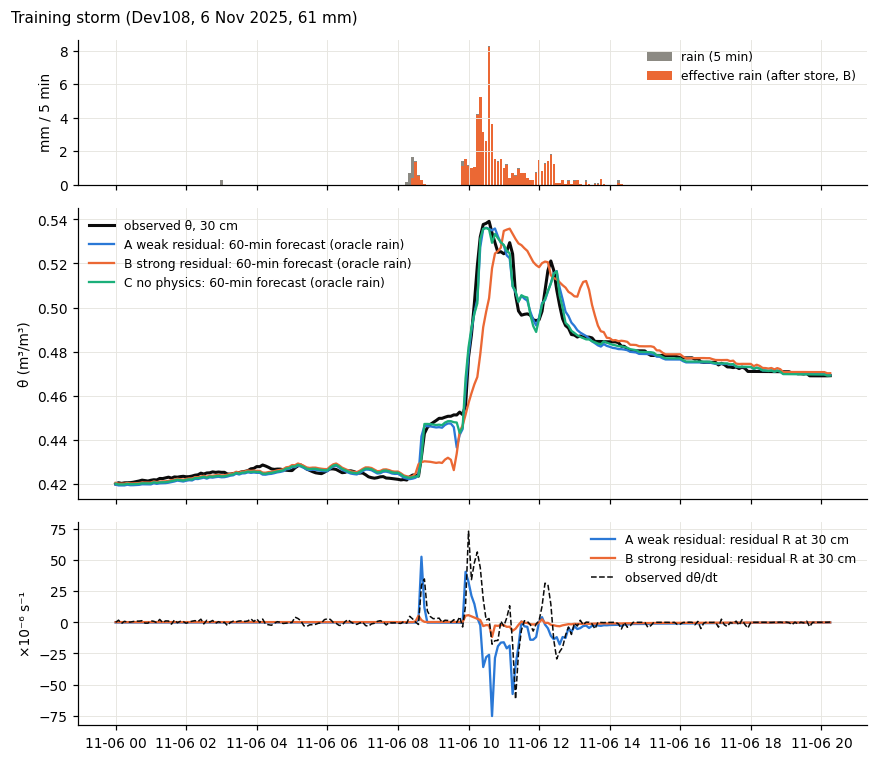

In [13]:
COL = {'A_weak': '#2a78d6', 'B_strong': '#eb6834', 'C_nophys': '#1baf7a'}
LBL = {'A_weak': 'A weak residual', 'B_strong': 'B strong residual', 'C_nophys': 'C no physics'}
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.color': '#e6e5e0',
                     'grid.linewidth': 0.6, 'font.size': 9, 'figure.dpi': 110})
os.makedirs('figs', exist_ok=True)

# Fig 1: training storm, 60-min oracle forecasts
w = win0; t = w['t']; sel = (t >= S108.start[0] - pd.Timedelta('3h')) & (t <= S108.end[0] + pd.Timedelta('6h'))
fig, ax = plt.subplots(3, 1, figsize=(8, 7), sharex=True, gridspec_kw=dict(height_ratios=[1, 2, 1.4]))
b = budget(models['B_strong'], w)
ax[0].bar(t[sel], w['rain'].numpy()[sel], width=0.003, color='#8c8a83', label='rain (5 min)')
ax[0].bar(t[sel], b['eff'][:, 0].numpy()[sel], width=0.003, color='#eb6834', label='effective rain (after store, B)')
ax[0].set_ylabel('mm / 5 min'); ax[0].legend(frameon=False, fontsize=8)
ax[1].plot(t[sel], w['obs'].numpy()[sel], color='#0b0b0b', lw=2, label='observed θ, 30 cm')
for tag, m in models.items():
    r = evaluate(m, w, oracle=True); idx = r['idx'].numpy(); pred = r['traj'][:, 11, I_OBS].numpy()
    tt = t[idx + 12]; ok = (tt >= t[sel][0]) & (tt <= t[sel][-1])
    ax[1].plot(tt[ok], pred[ok], color=COL[tag], lw=1.5, label=f'{LBL[tag]}: 60-min forecast (oracle rain)')
ax[1].set_ylabel('θ (m³/m³)'); ax[1].legend(frameon=False, fontsize=8)
for tag in ['A_weak', 'B_strong']:
    bb = budget(models[tag], w)
    ax[2].plot(t[1:][sel[1:]], bb['R'][:, I_OBS].numpy()[sel[1:]] * 1e6, color=COL[tag], lw=1.5, label=f'{LBL[tag]}: residual R at 30 cm')
ax[2].plot(t[1:][sel[1:]], np.diff(w['obs'].numpy())[sel[1:]] / DT * 1e6, color='#0b0b0b', lw=1, ls='--', label='observed dθ/dt')
ax[2].set_ylabel('×10⁻⁶ s⁻¹'); ax[2].legend(frameon=False, fontsize=8)
fig.suptitle('Training storm (Dev108, 6 Nov 2025, 61 mm)', x=0.01, ha='left', fontsize=10)
fig.tight_layout(); fig.savefig('figs/fig1_training_storm.png', dpi=200); plt.show()

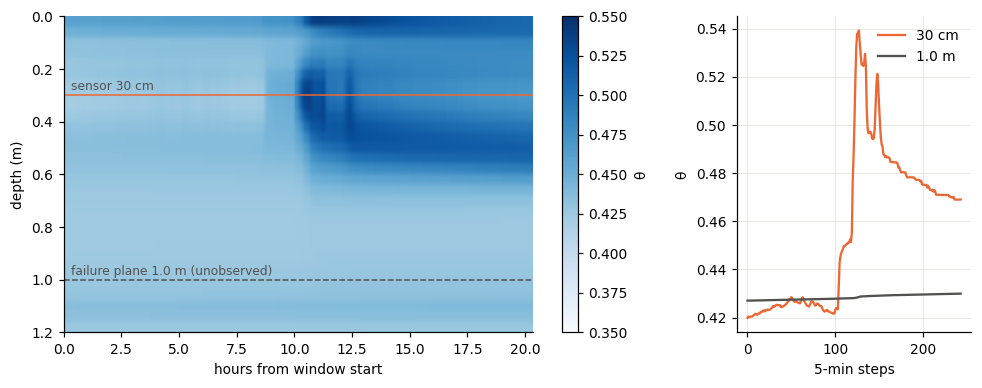

In [14]:
# Fig 2: latent profile theta(z,t) from the strong-residual PINN (analysis pass)
A = b['A'].numpy()
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6), gridspec_kw=dict(width_ratios=[3, 1.2]))
im = ax[0].imshow(A[sel].T, aspect='auto', cmap='Blues', vmin=0.35, vmax=0.55,
                  extent=[0, sel.sum() * 5 / 60, 1.2, 0])
ax[0].axhline(0.30, color='#eb6834', lw=1); ax[0].text(0.3, 0.28, 'sensor 30 cm', color='#52514e', fontsize=8)
ax[0].axhline(1.00, color='#52514e', lw=1, ls='--'); ax[0].text(0.3, 0.98, 'failure plane 1.0 m (unobserved)', color='#52514e', fontsize=8)
ax[0].set_xlabel('hours from window start'); ax[0].set_ylabel('depth (m)'); ax[0].grid(False)
plt.colorbar(im, ax=ax[0], label='θ')
ax[1].plot(A[sel][:, I_OBS], label='30 cm', color='#eb6834'); ax[1].plot(A[sel][:, list(I_FAIL)].mean(1), label='1.0 m', color='#52514e')
ax[1].set_xlabel('5-min steps'); ax[1].set_ylabel('θ'); ax[1].legend(frameon=False)
fig.tight_layout(); fig.savefig('figs/fig2_profile.png', dpi=200); plt.show()

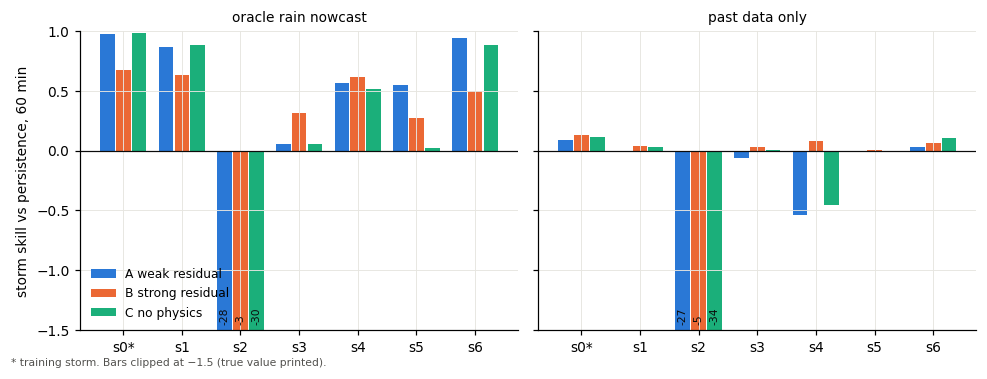

In [15]:
# Fig 3: storm-time 60-min skill per storm, oracle and past-only
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for k, mode in enumerate(['oracle', 'past']):
    d = SK[SK['mode'] == mode]
    for j, tag in enumerate(models):
        v = d[d.config == tag]['storm 60'].values
        ax[k].bar(np.arange(len(v)) + (j - 1) * 0.27, np.clip(v, -1.5, 1), width=0.25, color=COL[tag], label=LBL[tag])
        for x, y in zip(np.arange(len(v)) + (j - 1) * 0.27, v):
            if y < -1.5: ax[k].text(x, -1.45, f'{y:.0f}', rotation=90, fontsize=7, ha='center', va='bottom', color='#0b0b0b')
    ax[k].axhline(0, color='#0b0b0b', lw=0.8); ax[k].set_xticks(range(7)); ax[k].set_xticklabels([f's{i}' + ('*' if i == 0 else '') for i in range(7)])
    ax[k].set_title(f'{"oracle rain nowcast" if mode == "oracle" else "past data only"}', fontsize=9); ax[k].set_ylim(-1.5, 1)
ax[0].set_ylabel('storm skill vs persistence, 60 min'); ax[0].legend(frameon=False, fontsize=8, loc='lower left')
fig.text(0.01, 0.01, '* training storm. Bars clipped at −1.5 (true value printed).', fontsize=7, color='#52514e')
fig.tight_layout(); fig.savefig('figs/fig3_skill.png', dpi=200); plt.show()

## 8. Summary
The weak-residual PINN (A) fits the training storm through its residual rather than matrix flow (ρ_R ≈ 0.68); the independent solver with the same parameters loses most of the skill. See Figs. 5–6 of the manuscript.